In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Training Data.csv')

In [3]:
df

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
251995,251996,8154883,43,13,single,rented,no,Surgeon,Kolkata,West_Bengal,6,11,0
251996,251997,2843572,26,10,single,rented,no,Army_officer,Rewa,Madhya_Pradesh,6,11,0
251997,251998,4522448,46,7,single,rented,no,Design_Engineer,Kalyan-Dombivli,Maharashtra,7,12,0
251998,251999,6507128,45,0,single,rented,no,Graphic_Designer,Pondicherry,Puducherry,0,10,0


In [4]:
df.shape

(252000, 13)

In [5]:
df.head(20)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
5,6,6915937,64,0,single,rented,no,Civil_servant,Jalgaon,Maharashtra,0,12,0
6,7,3954973,58,14,married,rented,no,Librarian,Tiruppur,Tamil_Nadu,8,12,0
7,8,1706172,33,2,single,rented,no,Economist,Jamnagar,Gujarat,2,14,0
8,9,7566849,24,17,single,rented,yes,Flight_attendant,Kota[6],Rajasthan,11,11,0
9,10,8964846,23,12,single,rented,no,Architect,Karimnagar,Telangana,5,13,0


In [6]:
df = df.drop(columns=['Id'])

In [7]:
df.isnull().sum()

Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Income             252000 non-null  int64 
 1   Age                252000 non-null  int64 
 2   Experience         252000 non-null  int64 
 3   Married/Single     252000 non-null  object
 4   House_Ownership    252000 non-null  object
 5   Car_Ownership      252000 non-null  object
 6   Profession         252000 non-null  object
 7   CITY               252000 non-null  object
 8   STATE              252000 non-null  object
 9   CURRENT_JOB_YRS    252000 non-null  int64 
 10  CURRENT_HOUSE_YRS  252000 non-null  int64 
 11  Risk_Flag          252000 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 23.1+ MB


In [9]:
df.describe()

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [10]:
df['Age'].value_counts(normalize=True).head(10) * 100

Age
27    2.062302
66    2.020635
48    1.971032
33    1.952778
41    1.915476
45    1.907143
54    1.898810
68    1.893651
35    1.842460
50    1.834921
Name: proportion, dtype: float64

### bucket ages into ranges and compute percentages

In [11]:
# clean column (optional but recommended)
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# define bins
bins = [17, 30, 40, 50, 60, 100]
labels = ["17-30", "31-40", "41-50", "51-60", "60+"]

# create age groups
df["age_group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# distribution
age_distribution = (
    df["age_group"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(age_distribution)

age_group
17-30    17.32
31-40    16.47
41-50    17.26
51-60    16.88
60+      32.07
Name: proportion, dtype: float64


### Generic Function (Works for Age, Income, Experience)

In [12]:
def calculate_percentage_bins(df, column, bins, labels):
    # create bins
    df[f"{column}_group"] = pd.cut(
        df[column],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    
    # calculate percentage
    distribution = (
        df[f"{column}_group"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
    
    return distribution

### Experience Distribution

In [13]:
age_bins = [17, 30, 40, 50, 60, 100]
age_labels = ["17-30", "31-40", "41-50", "51-60", "60+"]

age_dist = calculate_percentage_bins(df, "Age", age_bins, age_labels)
print(age_dist)

Age_group
17-30    17.324206
31-40    16.465079
41-50    17.261508
51-60    16.880952
60+      32.068254
Name: proportion, dtype: float64


### Income Distribution

In [14]:
income_bins = [0, 2000000, 5000000, 8000000, 10000000]
income_labels = ["Low", "Lower-Mid", "Upper-Mid", "High"]

income_dist = calculate_percentage_bins(df, "Income", income_bins, income_labels)
print(income_dist)

Income_group
Low          19.935317
Lower-Mid    30.048016
Upper-Mid    30.415873
High         19.600794
Name: proportion, dtype: float64


In [15]:
df["Income_group"] = pd.qcut(df["Income"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])

income_dist = df["Income_group"].value_counts(normalize=True).sort_index() * 100
print(income_dist)

Income_group
Q1    25.000397
Q2    24.999603
Q3    25.004762
Q4    24.995238
Name: proportion, dtype: float64


### Experience Distribution

In [16]:
exp_bins = [0, 5, 10, 15, 20]
exp_labels = ["0-5", "6-10", "11-15", "15+"]

exp_dist = calculate_percentage_bins(df, "Experience", exp_bins, exp_labels)
print(exp_dist)

Experience_group
0-5      27.786508
6-10     24.277381
11-15    23.938095
15+      23.998016
Name: proportion, dtype: float64


### Combine All

In [17]:
summary_df = pd.DataFrame({
    "Age %": age_dist,
    "Income %": income_dist,
    "Experience %": exp_dist
})

print(summary_df)

           Age %   Income %  Experience %
0-5          NaN        NaN     27.786508
11-15        NaN        NaN     23.938095
15+          NaN        NaN     23.998016
17-30  17.324206        NaN           NaN
31-40  16.465079        NaN           NaN
41-50  17.261508        NaN           NaN
51-60  16.880952        NaN           NaN
6-10         NaN        NaN     24.277381
60+    32.068254        NaN           NaN
Q1           NaN  25.000397           NaN
Q2           NaN  24.999603           NaN
Q3           NaN  25.004762           NaN
Q4           NaN  24.995238           NaN


### categorical variables

In [18]:
df.describe(include=['O']).T  

,count,unique,top,freq
Married/Single,252000,2,single,226272
House_Ownership,252000,3,rented,231898
Car_Ownership,252000,2,no,176000
Profession,252000,51,Physician,5957
CITY,252000,317,Vijayanagaram,1259
STATE,252000,29,Uttar_Pradesh,28400


# EDA for Categorical Data

In [19]:
df['Profession'].value_counts(normalize=True).head(10) * 100

Profession
Physician                     2.363889
Statistician                  2.303968
Web_designer                  2.141667
Psychologist                  2.138889
Computer_hardware_engineer    2.131746
Drafter                       2.126587
Magistrate                    2.125794
Fashion_Designer              2.104762
Air_traffic_controller        2.095635
Comedian                      2.086905
Name: proportion, dtype: float64

In [20]:
df['Married/Single'].value_counts(normalize=True).head(10) * 100

Married/Single
single     89.790476
married    10.209524
Name: proportion, dtype: float64

In [21]:
df['House_Ownership'].value_counts(normalize=True).head(10) * 100

House_Ownership
rented          92.023016
owned            5.126190
norent_noown     2.850794
Name: proportion, dtype: float64

In [22]:
df['Car_Ownership'].value_counts(normalize=True).head(10) * 100

Car_Ownership
no     69.84127
yes    30.15873
Name: proportion, dtype: float64

In [23]:
df['CITY'].value_counts(normalize=True).head(10) * 100

CITY
Vijayanagaram    0.499603
Bhopal           0.479365
Bulandshahr      0.470238
Saharsa[29]      0.468254
Vijayawada       0.465079
Srinagar         0.450794
Indore           0.448413
New_Delhi        0.435714
Hajipur[31]      0.435714
Satara           0.434921
Name: proportion, dtype: float64

In [24]:
df['STATE'].value_counts(normalize=True).head(10) * 100

STATE
Uttar_Pradesh     11.269841
Maharashtra       10.143651
Andhra_Pradesh    10.038492
West_Bengal        9.318651
Bihar              7.849206
Tamil_Nadu         6.562302
Madhya_Pradesh     5.603968
Karnataka          4.704365
Gujarat            4.526984
Rajasthan          3.640476
Name: proportion, dtype: float64

### For each marital status, what percentage of people are ‘risky’?

In [25]:
df.groupby('Married/Single')['Risk_Flag'].mean().mul(100).sort_values(ascending=False)

Married/Single
single     12.533588
married    10.245647
Name: Risk_Flag, dtype: float64

#### Analysis

Among single individuals, ~12.5% are flagged as risky.
Among married individuals, ~10.2% are risky.

Singles have higher risk incidence

Absolute gap:

12.53% − 10.25% = 2.28 percentage points

Relative lift (risk ratio):

12.53 / 10.25 ≈ 1.22

Singles are ~22% more likely to be risky than married individuals.

### For each House_Ownership, what percentage of people are ‘risky’?

In [26]:
df.groupby(['House_Ownership'])['Risk_Flag'].mean().mul(100).sort_values(ascending=False)

House_Ownership
rented          12.557676
norent_noown     9.952673
owned            8.979718
Name: Risk_Flag, dtype: float64

### For each Profession, what percentage of people are ‘risky’?

In [27]:
df.groupby(['Profession'])['Risk_Flag'].mean().mul(100).sort_values(ascending=False).head(20)

Profession
Police_officer                16.405164
Chartered_Accountant          15.357222
Army_officer                  15.211328
Surveyor                      15.146373
Software_Developer            14.842668
Scientist                     14.432127
Geologist                     14.426370
Civil_engineer                13.583189
Official                      13.579643
Firefighter                   13.578877
Air_traffic_controller        13.539102
Hotel_Manager                 13.538046
Aviator                       13.493064
Technical_writer              13.416747
Architect                     13.120034
Secretary                     13.040901
Lawyer                        12.951432
Computer_hardware_engineer    12.844378
Technician                    12.828947
Biomedical_Engineer           12.755998
Name: Risk_Flag, dtype: float64

### For each City, what percentage of people are ‘risky’?

In [41]:
df.groupby(['CITY'])['Risk_Flag'].mean().mul(100).sort_values(ascending=False).head(10)

CITY
Bhubaneswar    32.619440
Gwalior        27.272727
Bettiah[33]    26.695842
Kochi          25.286160
Raiganj        23.955432
Purnia[26]     23.886640
Barasat        23.870220
Sikar          23.845194
Buxar[37]      23.147208
Satna          22.568093
Name: Risk_Flag, dtype: float64

### what percentage of people are ‘risky’?

In [28]:
df['Risk_Flag'].value_counts(normalize=True) * 100

Risk_Flag
0    87.7
1    12.3
Name: proportion, dtype: float64

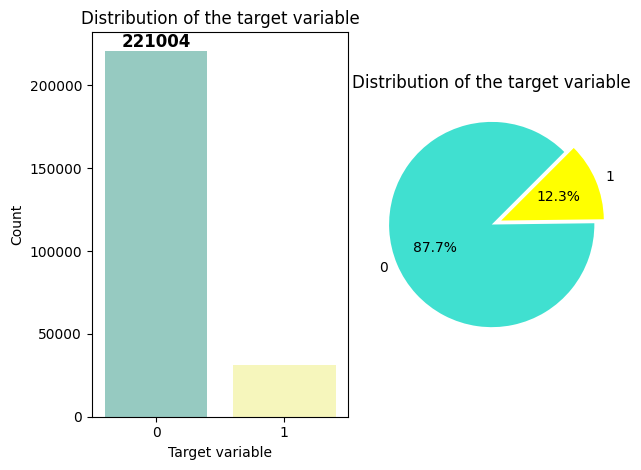

In [29]:
plt.subplot(1,2,1)
ax = sns.countplot(x='Risk_Flag', data=df, palette="Set3")
plt.title('Distribution of the target variable')
plt.xlabel('Target variable')
plt.ylabel('Count')
ax.bar_label(ax.containers[0], fontsize=12, color='black', fontweight='bold')
plt.subplot(1,2,2)
plt.pie(df.Risk_Flag.value_counts(), labels = df.Risk_Flag.value_counts().index, autopct = '%1.1f%%', startangle = 45, explode = (0, 0.1), colors = ['turquoise', 'yellow'] )
plt.title('Distribution of the target variable')
plt.tight_layout()
plt.show()

## Data Distribution

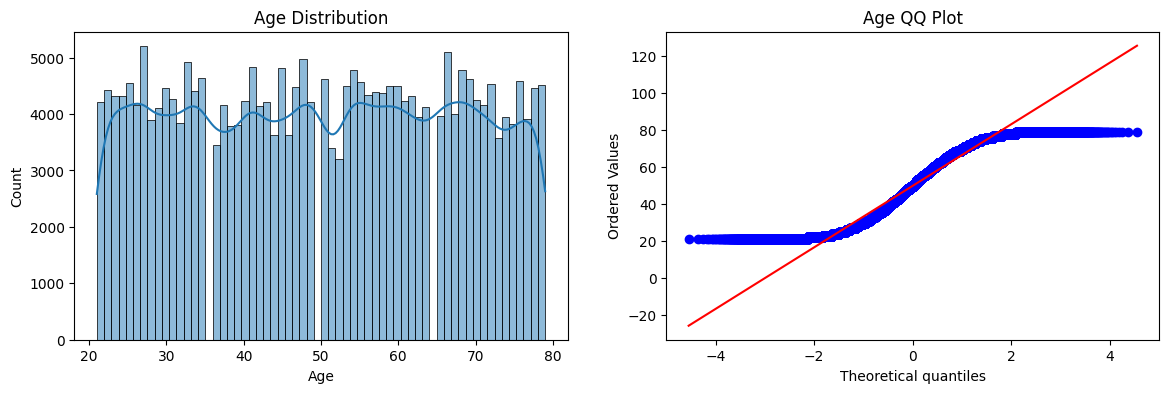

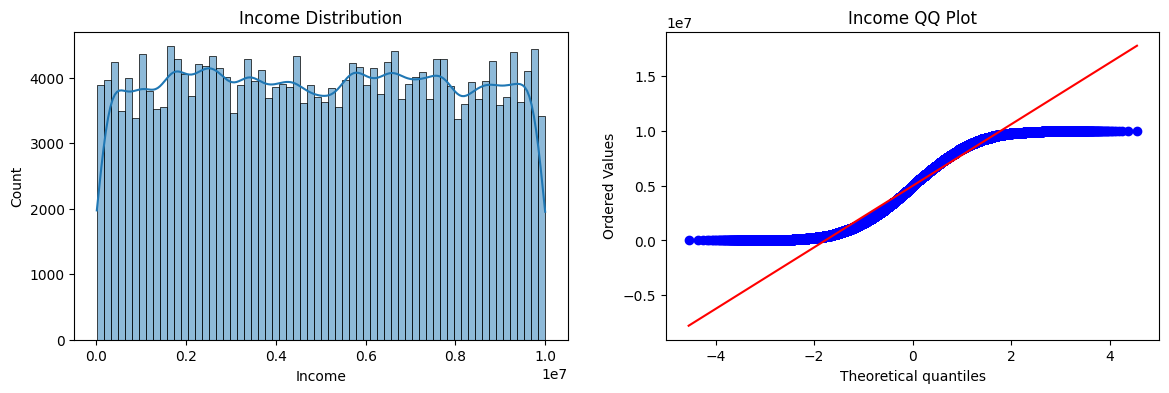

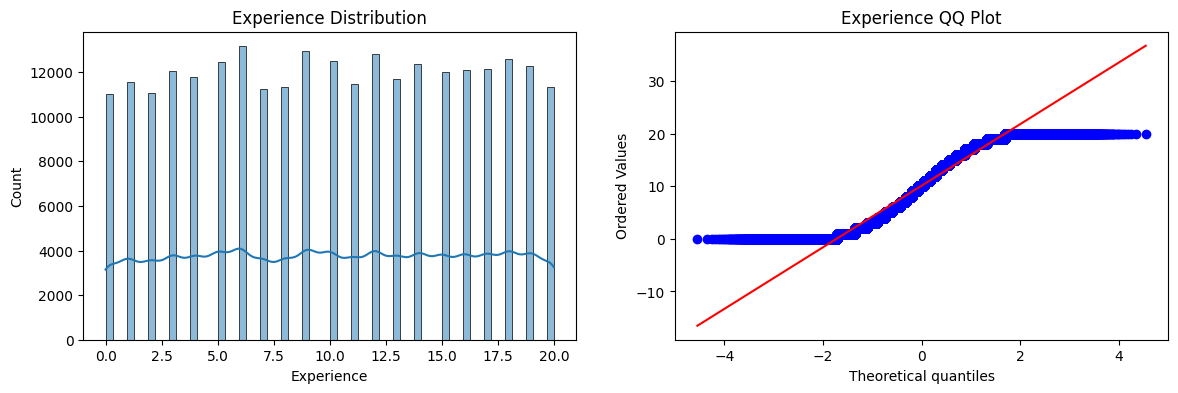

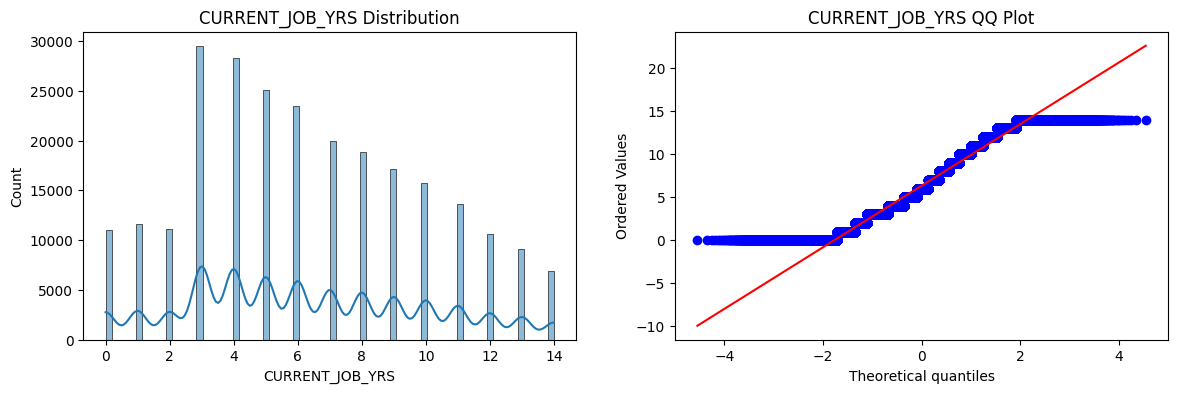

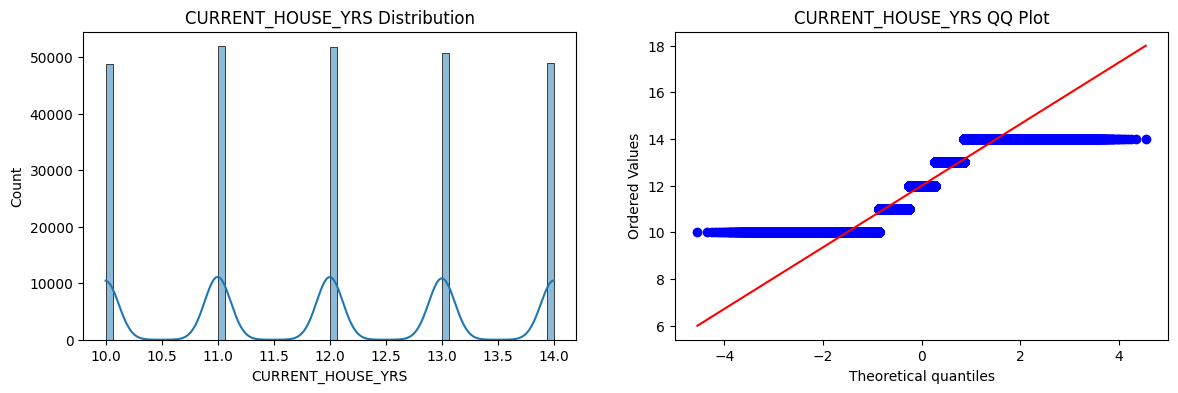

In [30]:
import seaborn as sns
import scipy.stats as stats

num_cols = ['Age','Income','Experience','CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS' ]

for col in num_cols:
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    sns.histplot(df[col], kde=True)
    plt.title(col + ' Distribution')
    
    plt.subplot(122)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(col + ' QQ Plot')
    
    plt.show()

In [31]:
df['Profession'].nunique()

51

In [32]:
df['Profession'].value_counts()

Profession
Physician                     5957
Statistician                  5806
Web_designer                  5397
Psychologist                  5390
Computer_hardware_engineer    5372
Drafter                       5359
Magistrate                    5357
Fashion_Designer              5304
Air_traffic_controller        5281
Comedian                      5259
Industrial_Engineer           5250
Mechanical_engineer           5217
Chemical_engineer             5205
Technical_writer              5195
Hotel_Manager                 5178
Financial_Analyst             5167
Graphic_Designer              5166
Flight_attendant              5128
Biomedical_Engineer           5127
Secretary                     5061
Software_Developer            5053
Petroleum_Engineer            5041
Police_officer                5035
Computer_operator             4990
Politician                    4944
Microbiologist                4881
Technician                    4864
Artist                        4861
Lawyer   

### Distribution of the current job years according to house ownership status

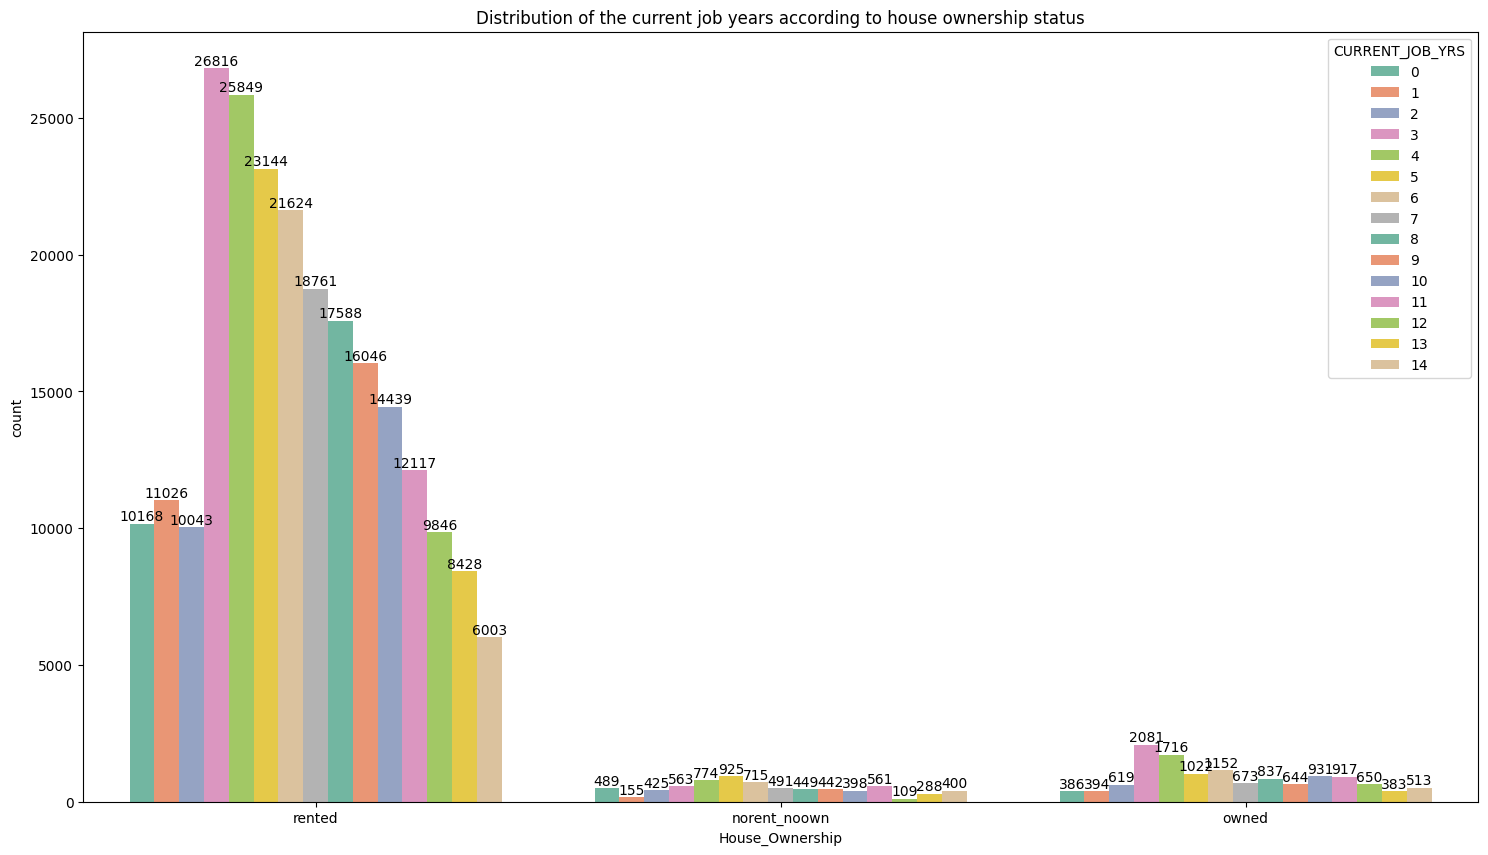

In [35]:
plt.figure(figsize=(18,10))
ax = sns.countplot(data = df , x=df["House_Ownership"], hue= "CURRENT_JOB_YRS", palette="Set2")
plt.title('Distribution of the current job years according to house ownership status')
for bars in ax.containers:
        ax.bar_label(bars);

### Visual of Risk Flag Respect to Top Features in Percentages

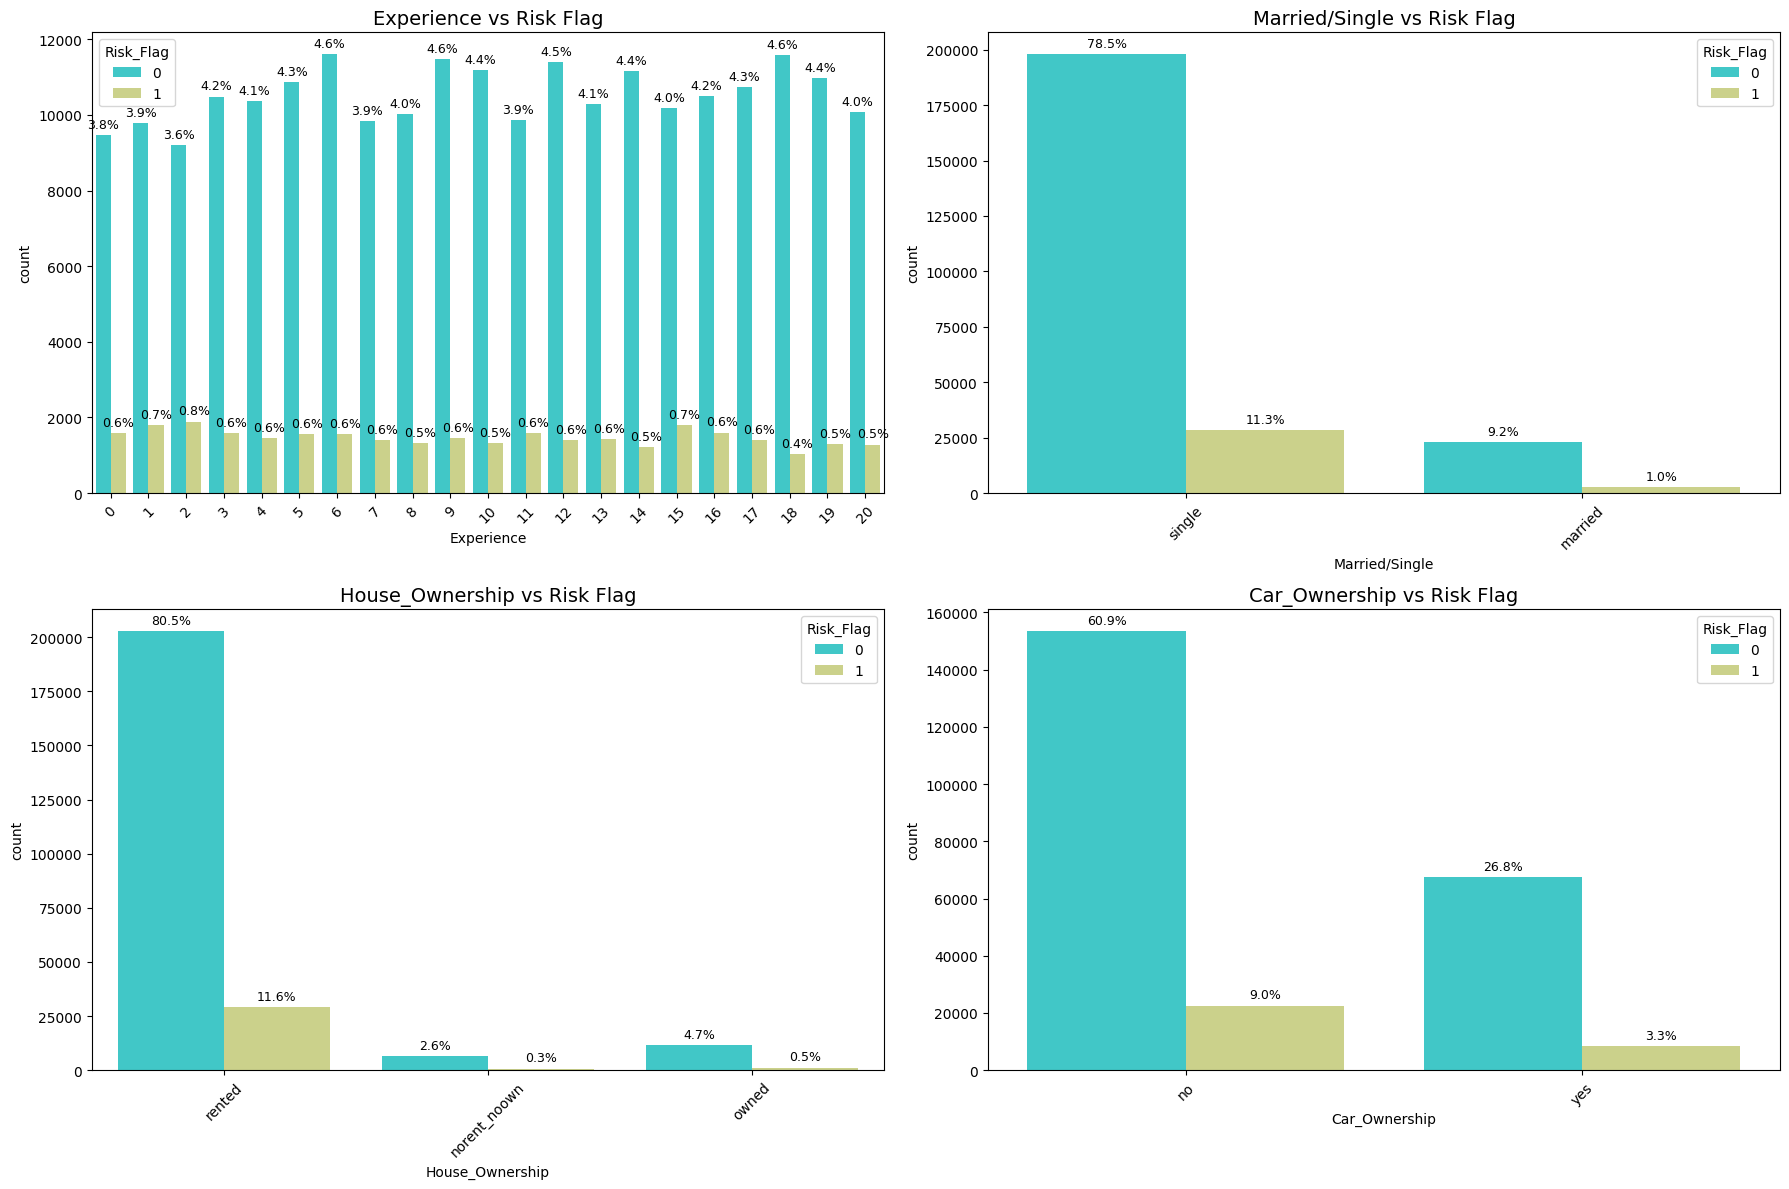

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Feature columns
features = [
    "Experience",
    "Married/Single",
    "House_Ownership",
    "Car_Ownership"
]

# Layout
n = len(features)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 6))
axes = axes.flatten()

# Total rows for percentage calculation
total = len(df)

for i, col in enumerate(features):

    ax = axes[i]

    # Countplot
    sns.countplot(
        x=col,
        data=df,
        hue='Risk_Flag',
        palette='rainbow',
        ax=ax
    )

    # Add percentage labels
    for container in ax.containers:

        labels = [
            f'{(v.get_height()/total)*100:.1f}%'
            for v in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

    # Titles and formatting
    ax.set_title(f'{col} vs Risk Flag', fontsize=14)
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplot if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# MODELLING STAGE

## Logistic Regression

In [51]:
dummy_df = df.drop(["CITY", "STATE"], axis=1)

In [52]:
dummy_df = pd.get_dummies(dummy_df, drop_first=True)

In [53]:
dummy_df

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Married/Single_single,House_Ownership_owned,House_Ownership_rented,Car_Ownership_yes,...,Age_group_31-40,Age_group_41-50,Age_group_51-60,Age_group_60+,Income_group_Q2,Income_group_Q3,Income_group_Q4,Experience_group_6-10,Experience_group_11-15,Experience_group_15+
0,1303834,23,3,3,13,0,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,7574516,40,10,9,13,0,True,False,True,False,...,True,False,False,False,False,False,True,True,False,False
2,3991815,66,4,4,10,0,False,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,6256451,41,2,2,12,1,True,False,True,True,...,False,True,False,False,False,True,False,False,False,False
4,5768871,47,11,3,14,1,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251995,8154883,43,13,6,11,0,True,False,True,False,...,False,True,False,False,False,False,True,False,True,False
251996,2843572,26,10,6,11,0,True,False,True,False,...,False,False,False,False,True,False,False,True,False,False
251997,4522448,46,7,7,12,0,True,False,True,False,...,False,True,False,False,True,False,False,True,False,False
251998,6507128,45,0,0,10,0,True,False,True,False,...,False,True,False,False,False,True,False,False,False,False


In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
X= dummy_df.drop(["Risk_Flag"], axis=1)
y= dummy_df["Risk_Flag"]

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=101)

In [79]:
X

,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Married/Single_single,House_Ownership_owned,House_Ownership_rented,Car_Ownership_yes,Profession_Analyst,...,Age_group_31-40,Age_group_41-50,Age_group_51-60,Age_group_60+,Income_group_Q2,Income_group_Q3,Income_group_Q4,Experience_group_6-10,Experience_group_11-15,Experience_group_15+
0,1303834,23,3,3,13,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,7574516,40,10,9,13,True,False,True,False,False,...,True,False,False,False,False,False,True,True,False,False
2,3991815,66,4,4,10,False,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
3,6256451,41,2,2,12,True,False,True,True,False,...,False,True,False,False,False,True,False,False,False,False
4,5768871,47,11,3,14,True,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251995,8154883,43,13,6,11,True,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
251996,2843572,26,10,6,11,True,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
251997,4522448,46,7,7,12,True,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
251998,6507128,45,0,0,10,True,False,True,False,False,...,False,True,False,False,False,True,False,False,False,False


In [80]:
y

0         0
1         0
2         0
3         1
4         1
         ..
251995    0
251996    0
251997    0
251998    0
251999    0
Name: Risk_Flag, Length: 252000, dtype: int64

In [57]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [82]:
X_train_scaled

array([[0.75357705, 0.68965517, 0.4       , ..., 1.        , 0.        ,
        0.        ],
       [0.76658865, 0.84482759, 0.8       , ..., 0.        , 0.        ,
        1.        ],
       [0.41042337, 0.37931034, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.45404877, 0.06896552, 0.7       , ..., 0.        , 1.        ,
        0.        ],
       [0.04209853, 0.20689655, 0.25      , ..., 0.        , 0.        ,
        0.        ],
       [0.24080372, 1.        , 1.        , ..., 0.        , 0.        ,
        1.        ]], shape=(201600, 73))

In [58]:
log_model=LogisticRegression(class_weight = "balanced")
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


def eval_metric(model, X_train, y_train, X_test, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test
    )

    plt.show()

Accuracy : 0.5401388888888888
Precision: 0.14640953015661445
Recall   : 0.5670269398290047
F1 Score : 0.23272751349025061

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.54      0.67     44201
           1       0.15      0.57      0.23      6199

    accuracy                           0.54     50400
   macro avg       0.52      0.55      0.45     50400
weighted avg       0.81      0.54      0.62     50400



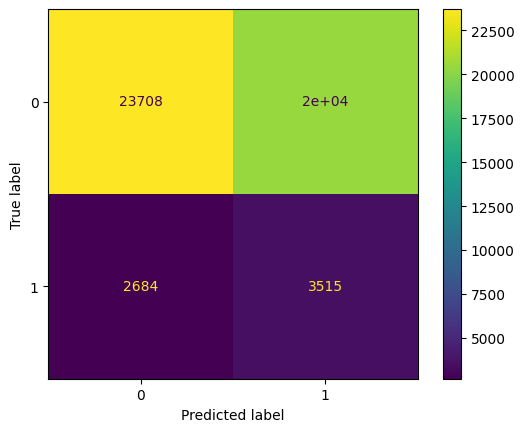

In [62]:
eval_metric(log_model, X_train_scaled, y_train, X_test_scaled, y_test)

In [67]:
LogisticRegression(
    class_weight='balanced',
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=1000,
    random_state=42
)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Accuracy : 0.5401388888888888
Precision: 0.14640953015661445
Recall   : 0.5670269398290047
F1 Score : 0.23272751349025061

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.54      0.67     44201
           1       0.15      0.57      0.23      6199

    accuracy                           0.54     50400
   macro avg       0.52      0.55      0.45     50400
weighted avg       0.81      0.54      0.62     50400



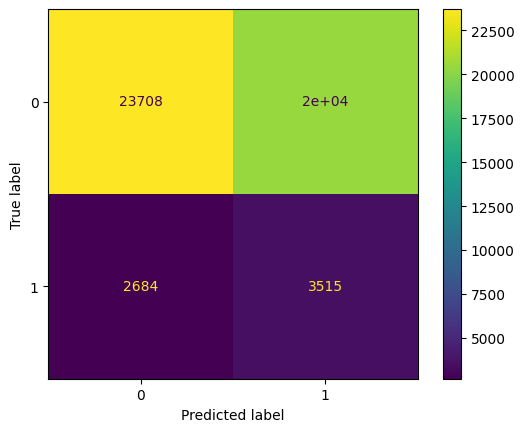

In [66]:
eval_metric(log_model, X_train_scaled, y_train, X_test_scaled, y_test)

[Text(0.5, 36.72222222222221, 'Predicted Class'),
 Text(95.72222222222221, 0.5, 'Actual Class')]

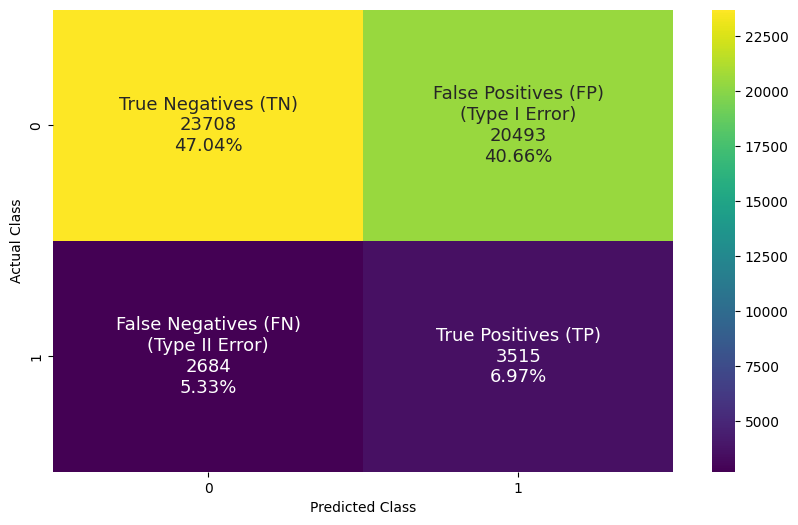

In [68]:
plt.figure(figsize=(10,6))

y_pred = log_model.predict(X_test_scaled)
cf_matrix = confusion_matrix(y_test, y_pred)

group_names = ['True Negatives (TN)', 'False Positives (FP)\n(Type I Error)', 
               'False Negatives (FN)\n(Type II Error)', 'True Positives (TP)']
group_counts = ['{0:0.0f}'.format(value) for value in cf_matrix.flatten()]
group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten()/np.sum(cf_matrix)]

labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]

labels = np.asarray(labels).reshape(2, 2)

ax = sns.heatmap(cf_matrix, annot=labels, fmt="", annot_kws={'size': 13}, cmap='viridis')
ax.set(xlabel='Predicted Class', ylabel = 'Actual Class')

## Evaluate Model

In [87]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## MAE

In [88]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.4598611111111111


## MSE

In [89]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.4598611111111111


## RMSE

In [90]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.6781306003352976


## R² Score

In [92]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -3.263183495971501


## Compare Actual vs Predicted

In [93]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
50097,1,0
191573,0,1
21124,0,0
143495,0,1
130873,0,1


## Residual Analysis

In [99]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
7,House_Ownership_rented,0.323687
46,Profession_Police_officer,0.290845
11,Profession_Army_officer,0.276027
54,Profession_Surveyor,0.266665
3,CURRENT_JOB_YRS,0.265833
5,Married/Single_single,0.222738
15,Profession_Chartered_Accountant,0.217532
72,Experience_group_15+,0.216494
51,Profession_Software_Developer,0.216133
34,Profession_Geologist,0.203872


## Residual Analysis

In [84]:
residuals = y_test - y_pred

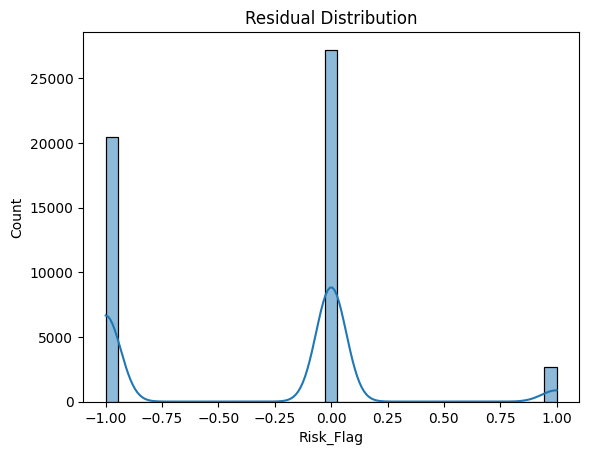

In [85]:
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

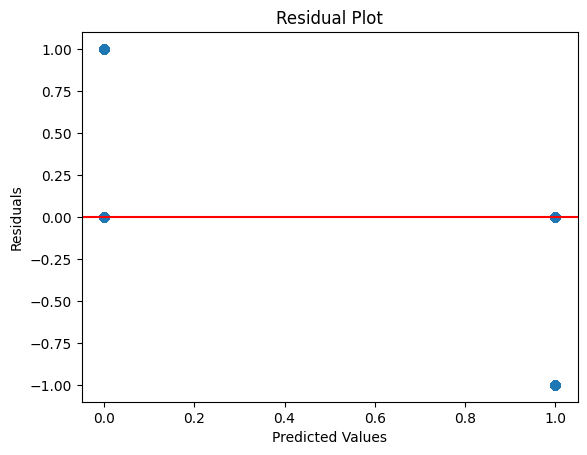

In [86]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [74]:
# =========================
# Model Selection
# =========================
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    GridSearchCV
)

# =========================
# Data Preprocessing
# =========================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc,
    make_scorer
)

# =========================
# Visualization Displays
# =========================
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

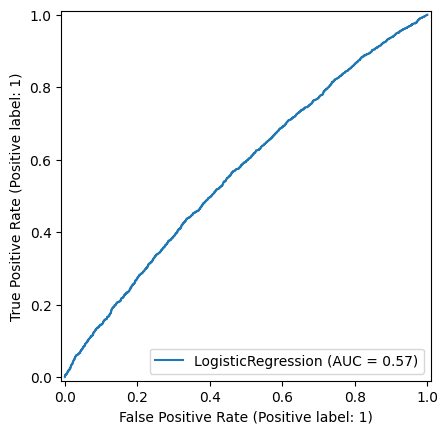

In [76]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

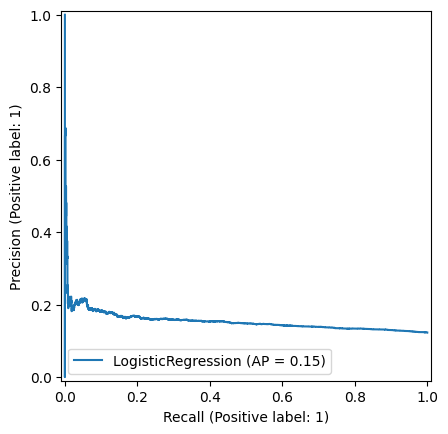

In [78]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)